# Train Audio Embedding Model for ESP32

Train a **small mel-spectrogram → 256-dim embedding** model that runs on ESP32.

## Key Insight
We don't need YAMNet! We train directly from mel-spectrograms:
- Audio: mel-spectrogram (64×96) → small CNN/MLP → 256-dim
- Text: MPNet (768-dim) → projection → 256-dim
- Contrastive learning aligns both in shared space

## Pipeline
1. Extract mel-spectrograms from audio files
2. Get text embeddings from MPNet
3. Train audio encoder (mel → 256) and text projection (768 → 256)
4. Export small TFLite model (~100-500KB) for ESP32
5. Export pre-computed text embeddings for similarity search

## Output
- `audio_encoder.tflite` (~100-500KB) - Runs on ESP32
- `embeddings.bin` - Pre-computed 256-dim text embeddings
- `intents.txt` - Question strings

## 1. Configuration

In [1]:
from pathlib import Path
import os

# Paths - vast.ai uses /workspace, local uses current dir
WORK_DIR = Path('/workspace') if Path('/workspace').exists() else Path('.').resolve()
AUDIO_DIR = WORK_DIR / 'audio_data'
MODEL_DIR = WORK_DIR / 'models'
DATA_DIR = WORK_DIR / 'data' / 'raw'
LOG_DIR = WORK_DIR / 'logs'

# Create directories
for d in [MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Embedding dimensions
YAMNET_DIM = 1024          # TF Hub YAMNet output
TEXT_DIM = 768             # MPNet output
EMBEDDING_DIM = 256        # Final projected dimension

# Audio specs
SAMPLE_RATE = 16000

# Training
BATCH_SIZE = 32
EPOCHS = 5000
LEARNING_RATE = 1e-4
TEMPERATURE = 0.2

# Suppress warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f"Work directory: {WORK_DIR}")
print(f"Audio directory: {AUDIO_DIR}")
print(f"Model directory: {MODEL_DIR}")
print(f"Running on: {'vast.ai' if Path('/workspace').exists() else 'local'}")
print(f"\nEmbedding pipeline: Audio({YAMNET_DIM}) + Text({TEXT_DIM}) -> {EMBEDDING_DIM}-dim")

Work directory: /workspace
Audio directory: /workspace/audio_data
Model directory: /workspace/models
Running on: vast.ai

Embedding pipeline: Audio(1024) + Text(768) -> 256-dim


## 2. Install Dependencies

In [2]:
# Install dependencies (vast.ai compatible with uv)
!uv add tensorflow tensorflow-hub librosa soundfile sentence-transformers pandas numpy matplotlib tqdm scikit-learn
print("Dependencies installed!")

Resolved 175 packages in 2ms
Audited 167 packages in 9ms
Dependencies installed!


In [3]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import librosa
import json
import struct
from glob import glob
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

print(f"TensorFlow: {tf.__version__}")

2025-11-29 11:28:21.218960: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0


## 3. Load TF Hub YAMNet

In [4]:
# Load TF Hub YAMNet - produces 1024-dim embeddings
print("Loading TF Hub YAMNet...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# YAMNet expects 16kHz mono audio waveform
# Outputs: scores (521 classes), embeddings (1024-dim per ~0.96s frame), log_mel_spectrogram
print("YAMNet loaded successfully!")
print(f"  Input: 16kHz mono audio waveform")
print(f"  Output: 1024-dim embedding per ~0.96s frame")

Loading TF Hub YAMNet...


I0000 00:00:1764415706.863686   17393 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14784 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:09:00.0, compute capability: 7.0


YAMNet loaded successfully!
  Input: 16kHz mono audio waveform
  Output: 1024-dim embedding per ~0.96s frame


In [5]:
# Test YAMNet with dummy audio
test_waveform = np.zeros(16000, dtype=np.float32)  # 1 second of silence
scores, embeddings, spectrogram = yamnet_model(test_waveform)

print("YAMNet output shapes:")
print(f"  Scores: {scores.shape} (521 AudioSet classes)")
print(f"  Embeddings: {embeddings.shape} (frames × 1024-dim)")
print(f"  Spectrogram: {spectrogram.shape}")

2025-11-29 11:28:31.411794: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


YAMNet output shapes:
  Scores: (2, 521) (521 AudioSet classes)
  Embeddings: (2, 1024) (frames × 1024-dim)
  Spectrogram: (144, 64)


## 4. Load Existing Audio Metadata

In [6]:
# Merge metadata from all GPU workers
print("Loading metadata from GPU workers...")

metadata = []
metadata_files = sorted(AUDIO_DIR.glob('metadata_worker_*.json'))

for mf in metadata_files:
    with open(mf) as f:
        worker_data = json.load(f)
        metadata.extend(worker_data)
        print(f"  {mf.name}: {len(worker_data)} entries")

print(f"\nTotal metadata entries: {len(metadata)}")

# Verify files exist
existing_files = []
for item in tqdm(metadata, desc="Verifying files"):
    if Path(item['file']).exists():
        existing_files.append(item)

print(f"\nExisting audio files: {len(existing_files)}")
metadata = existing_files

Loading metadata from GPU workers...
  metadata_worker_0.json: 2048 entries
  metadata_worker_1.json: 2672 entries
  metadata_worker_10.json: 2672 entries
  metadata_worker_11.json: 2736 entries
  metadata_worker_2.json: 2672 entries
  metadata_worker_3.json: 2672 entries
  metadata_worker_4.json: 2672 entries
  metadata_worker_5.json: 2672 entries
  metadata_worker_6.json: 2672 entries
  metadata_worker_7.json: 2672 entries
  metadata_worker_8.json: 2672 entries
  metadata_worker_9.json: 2672 entries

Total metadata entries: 31504


Verifying files: 100%|██████████| 31504/31504 [00:00<00:00, 69334.03it/s]


Existing audio files: 31504


In [7]:
# Load questions for text embeddings
qa_file = DATA_DIR / 'full.csv'
if qa_file.exists():
    qa_df = pd.read_csv(qa_file)
    questions = qa_df['question'].tolist()
    print(f"Loaded {len(questions)} questions from full.csv")
else:
    # Extract unique questions from metadata
    questions = list(dict.fromkeys([item['text'] for item in metadata]))
    print(f"Extracted {len(questions)} unique questions from metadata")

Loaded 2008 questions from full.csv


## 5. Mel-Spectrogram Generation

In [8]:
def load_audio(audio_path, target_sr=SAMPLE_RATE):
    """Load audio file and return waveform at 16kHz."""
    audio, sr = librosa.load(audio_path, sr=target_sr, mono=True)
    return audio.astype(np.float32)

def extract_yamnet_embedding(waveform):
    """Extract 1024-dim embedding using TF Hub YAMNet.
    
    Averages across all frames to get a single embedding per audio clip.
    """
    scores, embeddings, _ = yamnet_model(waveform)
    # Average across all frames to get single 1024-dim embedding
    return tf.reduce_mean(embeddings, axis=0).numpy()

# Test embedding extraction
test_audio = metadata[0]['file']
test_waveform = load_audio(test_audio)
test_embedding = extract_yamnet_embedding(test_waveform)

print(f"Test audio: {Path(test_audio).name}")
print(f"Waveform: {len(test_waveform)} samples ({len(test_waveform)/SAMPLE_RATE:.2f}s)")
print(f"Embedding shape: {test_embedding.shape}")
print(f"Embedding stats: mean={test_embedding.mean():.4f}, std={test_embedding.std():.4f}")

Test audio: q0039_s0.wav
Waveform: 48982 samples (3.06s)
Embedding shape: (1024,)
Embedding stats: mean=0.1099, std=0.1730


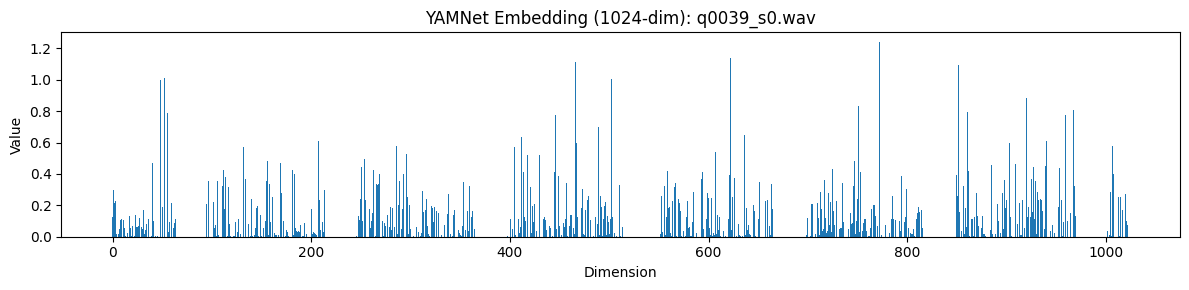

In [9]:
# Visualize test embedding
plt.figure(figsize=(12, 3))
plt.bar(range(len(test_embedding)), test_embedding)
plt.title(f'YAMNet Embedding (1024-dim): {Path(test_audio).name}')
plt.xlabel('Dimension')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

## 6. Extract YAMNet Embeddings for All Audio

In [10]:
# Check embedding dimensions
print(f"YAMNet output dimension: {YAMNET_DIM}")
print(f"Target embedding dimension: {EMBEDDING_DIM}")
print(f"Text encoder dimension: {TEXT_DIM}")

YAMNet output dimension: 1024
Target embedding dimension: 256
Text encoder dimension: 768


In [11]:
# Extract YAMNet embeddings for all audio files
print(f"Extracting YAMNet embeddings for {len(metadata)} audio files...")

audio_embeddings = []
valid_metadata = []

for item in tqdm(metadata):
    try:
        waveform = load_audio(item['file'])
        embedding = extract_yamnet_embedding(waveform)
        audio_embeddings.append(embedding)
        valid_metadata.append(item)
    except Exception as e:
        print(f"\nError processing {item['file']}: {e}")
        continue

audio_embeddings = np.array(audio_embeddings)
print(f"\nExtracted embeddings shape: {audio_embeddings.shape}")
print(f"Valid samples: {len(valid_metadata)}")

Extracting YAMNet embeddings for 31504 audio files...


100%|██████████| 31504/31504 [05:42<00:00, 91.97it/s] 



Extracted embeddings shape: (31504, 1024)
Valid samples: 31504


## 7. Prepare Text Embeddings

In [12]:
from sentence_transformers import SentenceTransformer

# Load text encoder
print("Loading MPNet text encoder...")
text_encoder = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Create bucket -> question index mapping
bucket_to_questions = defaultdict(list)
for i, item in enumerate(valid_metadata):
    bucket_id = item['bucket_id']
    bucket_to_questions[bucket_id].append(i)

print(f"Number of buckets: {len(bucket_to_questions)}")

Loading MPNet text encoder...
Number of buckets: 1680


In [13]:
# Get text embedding for each audio sample
print("Encoding text embeddings...")

# Get unique questions from metadata
unique_texts = list(dict.fromkeys([item['text'] for item in valid_metadata]))
text_to_embedding = {}

for text in tqdm(unique_texts):
    text_to_embedding[text] = text_encoder.encode(text)

# Map to each audio sample
text_embeddings = np.array([text_to_embedding[item['text']] for item in valid_metadata])
bucket_ids = np.array([item['bucket_id'] for item in valid_metadata])

print(f"Text embeddings shape: {text_embeddings.shape}")

Encoding text embeddings...


100%|██████████| 1948/1948 [00:34<00:00, 56.92it/s]

Text embeddings shape: (31504, 768)


## 8. Train Text Projection

Since YAMNet-256 outputs 256-dim directly, we:
- Keep audio embeddings as-is (256-dim)
- Train text projection: 768 -> 256

This aligns text embeddings to the YAMNet-256 embedding space.

In [14]:
# Projection models to align audio and text in shared 256-dim embedding space
# Audio: 1024 -> 256
# Text: 768 -> 256

audio_projection = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(YAMNET_DIM,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(EMBEDDING_DIM),
    tf.keras.layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))
], name='audio_projection')

text_projection = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TEXT_DIM,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(EMBEDDING_DIM),
    tf.keras.layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))
], name='text_projection')

print(f"Audio Projection (1024 -> {EMBEDDING_DIM}):")
audio_projection.summary()
print(f"\nText Projection (768 -> {EMBEDDING_DIM}):")
text_projection.summary()

Audio Projection (1024 -> 256):


Model: "audio_projection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,272 (2.53 MB)

 Trainable params: 659,200 (2.51 MB)

...

Model: "text_projection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_2           │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,176 (2.02 MB)

 Trainable params: 527,616 (2.01 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [15]:
# Normalize audio embeddings (L2 norm)
audio_embeddings_normalized = audio_embeddings / (np.linalg.norm(audio_embeddings, axis=1, keepdims=True) + 1e-8)
print(f"Audio embeddings normalized: shape={audio_embeddings_normalized.shape}")

Audio embeddings normalized: shape=(31504, 1024)


In [16]:
# Bucketed batch generator (same as original)
import random

class BucketedBatchGenerator:
    def __init__(self, audio_embs, text_embs, bucket_ids, batch_size):
        self.audio_embs = audio_embs
        self.text_embs = text_embs
        self.bucket_ids = bucket_ids
        self.batch_size = batch_size
        
        self.bucket_to_indices = defaultdict(list)
        for idx, bid in enumerate(bucket_ids):
            self.bucket_to_indices[bid].append(idx)
        
        self.all_buckets = list(self.bucket_to_indices.keys())
        
        if batch_size > len(self.all_buckets):
            self.batch_size = len(self.all_buckets)
    
    def __len__(self):
        return len(self.audio_embs) // self.batch_size
    
    def generate_batch(self):
        selected_buckets = random.sample(self.all_buckets, self.batch_size)
        
        batch_audio = []
        batch_text = []
        
        for bucket_id in selected_buckets:
            idx = random.choice(self.bucket_to_indices[bucket_id])
            batch_audio.append(self.audio_embs[idx])
            batch_text.append(self.text_embs[idx])
        
        return np.array(batch_audio), np.array(batch_text)
    
    def generate_epoch(self):
        for _ in range(len(self)):
            yield self.generate_batch()

batch_generator = BucketedBatchGenerator(
    audio_embeddings_normalized,
    text_embeddings,
    bucket_ids,
    BATCH_SIZE
)

print(f"Batch generator: {len(batch_generator)} batches per epoch")

Batch generator: 984 batches per epoch


In [17]:
# Contrastive loss for audio-text alignment
class ContrastiveLoss(tf.keras.losses.Loss):
    def __init__(self, temperature=0.2, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature
    
    def call(self, audio_emb, text_emb):
        # Both inputs should be L2 normalized
        logits = tf.matmul(audio_emb, text_emb, transpose_b=True) / self.temperature
        batch_size = tf.shape(audio_emb)[0]
        labels = tf.range(batch_size)
        
        loss_a2t = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        loss_t2a = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=tf.transpose(logits))
        
        return (tf.reduce_mean(loss_a2t) + tf.reduce_mean(loss_t2a)) / 2

optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
loss_fn = ContrastiveLoss(temperature=TEMPERATURE)

# Get all trainable variables from both projections
all_trainable = audio_projection.trainable_variables + text_projection.trainable_variables

@tf.function
def train_step(audio_batch, text_batch):
    with tf.GradientTape() as tape:
        # Project both audio and text to shared 256-dim space
        audio_proj = audio_projection(audio_batch, training=True)  # 1024 -> 256
        text_proj = text_projection(text_batch, training=True)      # 768 -> 256
        loss = loss_fn(audio_proj, text_proj)
    
    gradients = tape.gradient(loss, all_trainable)
    optimizer.apply_gradients(zip(gradients, all_trainable))
    return loss

print("Training setup complete - both audio and text projections will be trained")

Training setup complete - both audio and text projections will be trained


In [ ]:
# Training loop
print(f"Training text projection for {EPOCHS} epochs...")

history = {'loss': []}
best_loss = float('inf')

for epoch in range(1000):
    epoch_losses = []
    
    for audio_batch, text_batch in batch_generator.generate_epoch():
        audio_batch = tf.constant(audio_batch, dtype=tf.float32)
        text_batch = tf.constant(text_batch, dtype=tf.float32)
        
        loss = train_step(audio_batch, text_batch)
        epoch_losses.append(loss.numpy())
    
    avg_loss = np.mean(epoch_losses)
    history['loss'].append(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Best: {best_loss:.4f}")

print(f"\nTraining complete! Best loss: {best_loss:.4f}")

Training text projection for 5000 epochs...
Epoch 50/5000 - Loss: 1.6026 - Best: 1.5979


In [ ]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'])
plt.title('Text Projection Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.grid(True)
plt.savefig(str(MODEL_DIR / 'yamnet256_training_loss.png'), dpi=150)
plt.show()

## 9. Evaluation

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Project audio and text embeddings to shared space
audio_projected = audio_projection.predict(audio_embeddings_normalized)
text_projected = text_projection.predict(text_embeddings)

# Sample for evaluation
sample_size = min(500, len(audio_projected))
similarity_matrix = cosine_similarity(
    audio_projected[:sample_size],
    text_projected[:sample_size]
)

# Bucket matching accuracy
predictions = np.argmax(similarity_matrix, axis=1)
pred_buckets = bucket_ids[:sample_size][predictions]
true_buckets = bucket_ids[:sample_size]
bucket_accuracy = np.mean(pred_buckets == true_buckets)

print(f"\n{'='*60}")
print(f"EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Audio: 1024-dim -> {EMBEDDING_DIM}-dim")
print(f"Text: 768-dim -> {EMBEDDING_DIM}-dim")
print(f"Bucket Matching Accuracy: {bucket_accuracy*100:.2f}%")
print(f"Mean diagonal similarity: {np.mean(np.diag(similarity_matrix)):.3f}")
print(f"Mean off-diagonal: {np.mean(similarity_matrix[~np.eye(sample_size, dtype=bool)]):.3f}")

## 10. Export for ESP32

In [ ]:
# Generate query embeddings (text -> 256-dim, for similarity search on ESP32)
print("Generating query embeddings for ESP32...")

# Get unique questions (preserve order from full.csv)
unique_questions = questions
print(f"Unique questions: {len(unique_questions)}")

# Encode text and project to 256-dim
query_text_embeddings = text_encoder.encode(unique_questions)
query_embeddings = text_projection.predict(query_text_embeddings)

print(f"Query embeddings shape: {query_embeddings.shape}")

In [ ]:
# Save embeddings.bin (for ESP32 similarity search)
embeddings_path = MODEL_DIR / 'embeddings.bin'
with open(embeddings_path, 'wb') as f:
    for emb in query_embeddings:
        f.write(struct.pack(f'{EMBEDDING_DIM}f', *emb))

print(f"Query embeddings saved: {embeddings_path}")
print(f"  Count: {len(query_embeddings)}")
print(f"  Dimensions: {EMBEDDING_DIM}")
print(f"  Size: {embeddings_path.stat().st_size / 1024:.2f} KB")

# Save intents.txt
intents_path = MODEL_DIR / 'intents.txt'
with open(intents_path, 'w') as f:
    for q in unique_questions:
        f.write(f"{q}\n")

print(f"\nIntent texts saved: {intents_path}")
print(f"  Count: {len(unique_questions)}")

In [ ]:
# Save projection models (Keras H5 format)
audio_projection.save(str(MODEL_DIR / 'audio_projection.h5'))
text_projection.save(str(MODEL_DIR / 'text_projection.h5'))
print("Saved Keras models:")
print(f"  audio_projection.h5 (1024 -> {EMBEDDING_DIM})")
print(f"  text_projection.h5 (768 -> {EMBEDDING_DIM})")

# Convert text projection to TFLite (for potential on-device text encoding)
converter = tf.lite.TFLiteConverter.from_keras_model(text_projection)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'text_projection.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nText projection TFLite: {tflite_path}")
print(f"  Size: {len(tflite_model) / 1024:.2f} KB")

In [ ]:
# Summary of all saved files
print("="*60)
print("ALL OUTPUT FILES")
print("="*60)

for f in sorted(MODEL_DIR.glob('*')):
    if f.is_file():
        size = f.stat().st_size
        if size > 1024*1024:
            print(f"  {f.name}: {size/1024/1024:.2f} MB")
        else:
            print(f"  {f.name}: {size/1024:.1f} KB")

print(f"\n✓ Ready for ESP32 deployment!")

## 11. Summary

In [ ]:
print("="*60)
print("EMBEDDING TRAINING COMPLETE")
print("="*60)

print(f"\nDataset:")
print(f"  Audio samples: {len(audio_embeddings)}")
print(f"  Unique questions: {len(unique_questions)}")
print(f"  Buckets: {len(bucket_to_questions)}")

print(f"\nModel Performance:")
print(f"  Final loss: {history['loss'][-1]:.4f}")
print(f"  Bucket accuracy: {bucket_accuracy*100:.2f}%")

print(f"\nEmbedding Dimensions:")
print(f"  YAMNet audio: 1024 -> {EMBEDDING_DIM}")
print(f"  MPNet text: 768 -> {EMBEDDING_DIM}")

print(f"\nOutput Files for ESP32:")
for f in sorted(MODEL_DIR.glob('*')):
    if f.is_file():
        size = f.stat().st_size
        if size > 1024*1024:
            print(f"  {f.name}: {size/1024/1024:.2f} MB")
        else:
            print(f"  {f.name}: {size/1024:.1f} KB")

print(f"\nFor ESP32 deployment:")
print(f"  Copy models/embeddings.bin -> SD:/data/embeddings.bin")
print(f"  Copy models/intents.txt -> SD:/data/intents.txt")
print(f"\n⚠️  NOTE: ESP32 will need a small on-device model to extract")
print(f"   audio embeddings from recorded speech. Options:")
print(f"   1. Train a small MLP on mel-spectrograms")
print(f"   2. Use a distilled audio encoder")
print(f"   3. Run YAMNet-lite if available")